# Sales Data Analysis Project

## AIML Internship Assignment

### Dataset Tables

- Customers
- Products
- Orders

### Tools Used

- Python
- Pandas
- NumPy
- SQLite
- Matplotlib
- Seaborn

In [4]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")

In [6]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [7]:
display(customers)
display(products)
display(orders)

,customer_id,name,region,segment
0,C001,Gopal,North,Student
1,C002,Rahul,South,Professional
2,C003,Priya,West,Student
3,C004,Aman,East,Business
4,C005,Neha,North,Professional
5,C006,Rohan,South,Business


,product_id,product_name,category,price
0,P001,Laptop,Electronics,50000
1,P002,Mouse,Electronics,800
2,P003,Keyboard,Electronics,1500
3,P004,Notebook,Stationery,100
4,P005,Pen,Stationery,20
5,P006,Backpack,Accessories,1200


,order_id,customer_id,product_id,quantity,order_date
0,O001,C001,P001,1,2025-01-10
1,O002,C002,P002,2,2025-01-12
2,O003,C003,P004,10,2025-01-15
3,O004,C004,P006,1,2025-02-01
4,O005,C005,P003,2,2025-02-10
5,O006,C006,P001,1,2025-02-15
6,O007,C001,P005,5,2025-03-05
7,O008,C003,P002,1,2025-03-12
8,O009,C005,P006,2,2025-03-20
9,O010,C002,P004,8,2025-04-01


In [8]:
print("Customers Shape:", customers.shape)
print("Products Shape:", products.shape)
print("Orders Shape:", orders.shape)

Customers Shape: (6, 4)
Products Shape: (6, 4)
Orders Shape: (10, 5)


In [9]:
customers.info()
print("\n")

products.info()
print("\n")

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  6 non-null      str  
 1   name         6 non-null      str  
 2   region       6 non-null      str  
 3   segment      6 non-null      str  
dtypes: str(4)
memory usage: 320.0 bytes


<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    6 non-null      str  
 1   product_name  6 non-null      str  
 2   category      6 non-null      str  
 3   price         6 non-null      int64
dtypes: int64(1), str(3)
memory usage: 320.0 bytes


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   order_id     10 non-null     str  
 1   customer_id  10 non-null 

In [10]:
print("Customers Missing Values")
print(customers.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

print("\nOrders Missing Values")
print(orders.isnull().sum())

Customers Missing Values
customer_id    0
name           0
region         0
segment        0
dtype: int64

Products Missing Values
product_id      0
product_name    0
category        0
price           0
dtype: int64

Orders Missing Values
order_id       0
customer_id    0
product_id     0
quantity       0
order_date     0
dtype: int64


In [11]:
products.describe()

,price
count,6.000000
mean,8936.666667
std,20125.388609
min,20.000000
25%,275.000000
50%,1000.000000
75%,1425.000000
max,50000.000000


In [12]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     10 non-null     str           
 1   customer_id  10 non-null     str           
 2   product_id   10 non-null     str           
 3   quantity     10 non-null     int64         
 4   order_date   10 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 528.0 bytes


In [13]:
print("Customers duplicates:",
      customers.duplicated().sum())

print("Products duplicates:",
      products.duplicated().sum())

print("Orders duplicates:",
      orders.duplicated().sum())

Customers duplicates: 0
Products duplicates: 0
Orders duplicates: 0


In [14]:
customers.head()

,customer_id,name,region,segment
0,C001,Gopal,North,Student
1,C002,Rahul,South,Professional
2,C003,Priya,West,Student
3,C004,Aman,East,Business
4,C005,Neha,North,Professional


In [15]:
products.groupby("category")["price"].mean()

category
Accessories     1200.000000
Electronics    17433.333333
Stationery        60.000000
Name: price, dtype: float64

In [16]:
orders.groupby("customer_id").size()

customer_id
C001    2
C002    2
C003    2
C004    1
C005    2
C006    1
dtype: int64

In [17]:
merged = orders.merge(
    customers,
    on="customer_id"
)

merged.groupby(
    ["region", "segment"]
).size()

region  segment     
East    Business        1
North   Professional    2
        Student         2
South   Business        1
        Professional    2
West    Student         2
dtype: int64

In [18]:
sales = orders.merge(
    customers,
    on="customer_id"
).merge(
    products,
    on="product_id"
)

sales.head()

,order_id,customer_id,product_id,quantity,order_date,name,region,segment,product_name,category,price
0,O001,C001,P001,1,2025-01-10,Gopal,North,Student,Laptop,Electronics,50000
1,O002,C002,P002,2,2025-01-12,Rahul,South,Professional,Mouse,Electronics,800
2,O003,C003,P004,10,2025-01-15,Priya,West,Student,Notebook,Stationery,100
3,O004,C004,P006,1,2025-02-01,Aman,East,Business,Backpack,Accessories,1200
4,O005,C005,P003,2,2025-02-10,Neha,North,Professional,Keyboard,Electronics,1500


In [19]:
sales["revenue"] = (
    sales["quantity"] * sales["price"]
)

sales[[
    "order_id",
    "product_name",
    "quantity",
    "price",
    "revenue"
]]

,order_id,product_name,quantity,price,revenue
0,O001,Laptop,1,50000,50000
1,O002,Mouse,2,800,1600
2,O003,Notebook,10,100,1000
3,O004,Backpack,1,1200,1200
4,O005,Keyboard,2,1500,3000
5,O006,Laptop,1,50000,50000
6,O007,Pen,5,20,100
7,O008,Mouse,1,800,800
8,O009,Backpack,2,1200,2400
9,O010,Notebook,8,100,800


In [20]:
sales["revenue"].sum()

np.int64(110900)

In [21]:
sales["revenue"].mean()

np.float64(11090.0)

In [22]:
sales.groupby("product_name")["revenue"].sum()

product_name
Backpack      3600
Keyboard      3000
Laptop      100000
Mouse         2400
Notebook      1800
Pen            100
Name: revenue, dtype: int64

In [23]:
sales.groupby(
    "product_name"
)["revenue"].sum().sort_values(
    ascending=False
)

product_name
Laptop      100000
Backpack      3600
Keyboard      3000
Mouse         2400
Notebook      1800
Pen            100
Name: revenue, dtype: int64

In [24]:
pd.pivot_table(
    sales,
    values="revenue",
    index="region",
    aggfunc="sum"
)

,revenue
region,
East,1200
North,55500
South,52400
West,1800


In [25]:
pd.pivot_table(
    sales,
    values="revenue",
    index="category",
    columns="region",
    aggfunc="sum",
    fill_value=0
)

region,East,North,South,West
category,,,,
Accessories,1200,2400,0,0
Electronics,0,53000,51600,800
Stationery,0,100,800,1000


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries installed successfully")

Libraries installed successfully


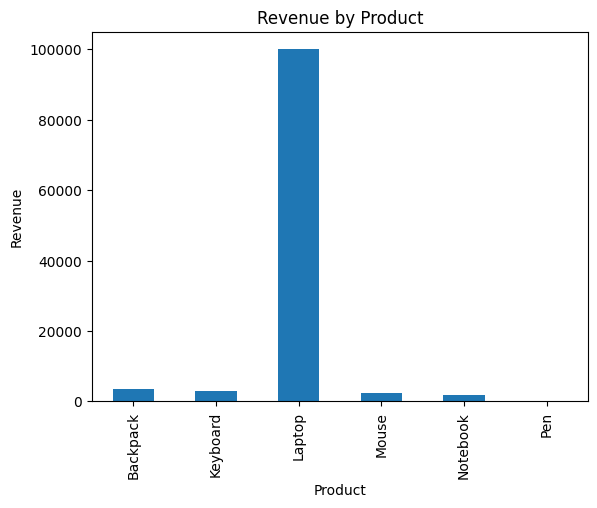

In [28]:
sales.groupby("product_name")["revenue"].sum().plot(
    kind="bar"
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

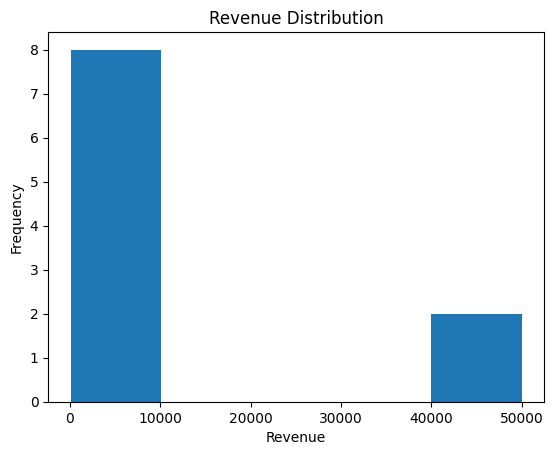

In [29]:
sales["revenue"].plot(
    kind="hist",
    bins=5
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

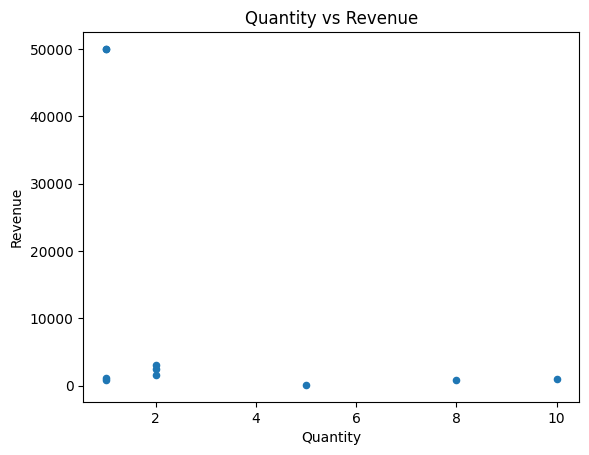

In [30]:
sales.plot(
    kind="scatter",
    x="quantity",
    y="revenue"
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

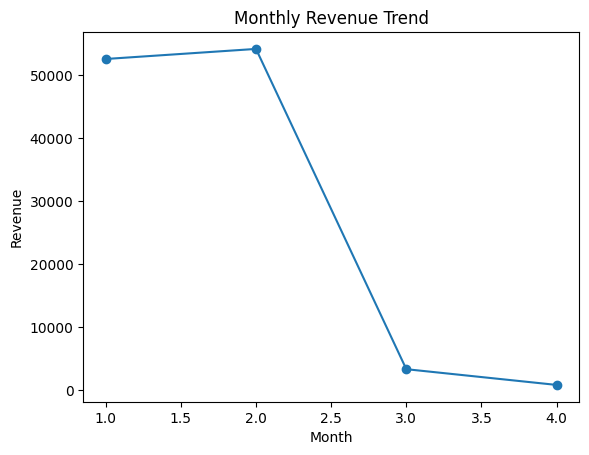

In [32]:
monthly_revenue = sales.groupby(
    sales["order_date"].dt.month
)["revenue"].sum()

monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

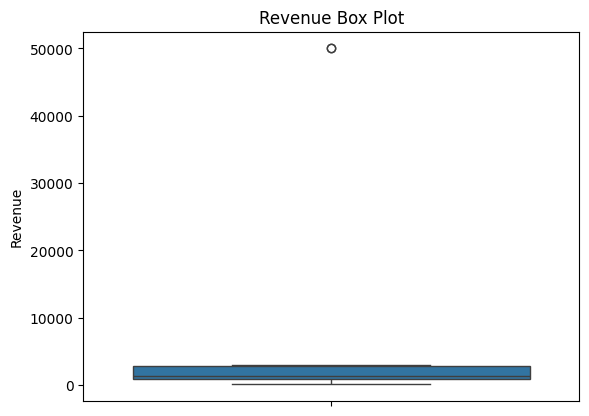

In [34]:
import seaborn as sns

sns.boxplot(
    y=sales["revenue"]
)

plt.title("Revenue Box Plot")
plt.ylabel("Revenue")
plt.show()

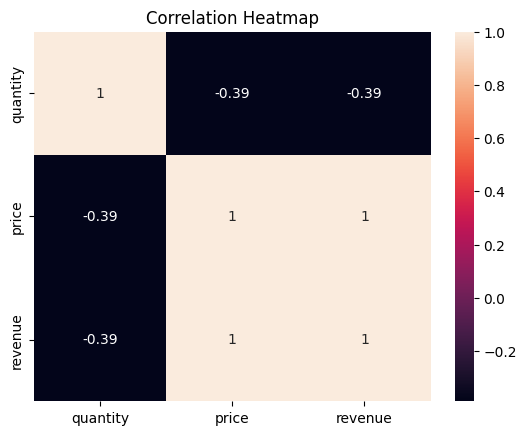

In [35]:
correlation = sales[["quantity", "price", "revenue"]].corr()

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

## Business Insights from the Analysis

1. Electronics generated the highest revenue among all product categories, primarily due to laptop sales.
2. The Laptop product was the top-performing item, contributing significantly more revenue than any other product.
3. Revenue was concentrated in a few high-value orders, which is visible from the histogram and box plot.
4. North and South regions generated more orders compared to other regions, indicating stronger customer activity.
5. Professional and Student customer segments were the most active segments in the dataset.
6. The scatter plot showed that revenue generally increases with quantity and product price.
7. Monthly revenue trends indicate fluctuations in sales performance across different months.
8. The heatmap confirmed a strong relationship between price and revenue, highlighting the importance of high-value products.


In [36]:
import sqlite3

conn = sqlite3.connect("sales.db")

print("Database created successfully")

Database created successfully


In [37]:
customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

print("Tables loaded into SQLite")

Tables loaded into SQLite


In [38]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,customers
1,products
2,orders


In [39]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,customers
1,products
2,orders


In [40]:
query = """
SELECT *
FROM products;
"""

pd.read_sql(query, conn)

,product_id,product_name,category,price
0,P001,Laptop,Electronics,50000
1,P002,Mouse,Electronics,800
2,P003,Keyboard,Electronics,1500
3,P004,Notebook,Stationery,100
4,P005,Pen,Stationery,20
5,P006,Backpack,Accessories,1200


In [41]:
query = """
SELECT *
FROM products
WHERE price > 1000;
"""

pd.read_sql(query, conn)

,product_id,product_name,category,price
0,P001,Laptop,Electronics,50000
1,P003,Keyboard,Electronics,1500
2,P006,Backpack,Accessories,1200


In [42]:
query = """
SELECT *
FROM orders
ORDER BY quantity DESC;
"""

pd.read_sql(query, conn)

,order_id,customer_id,product_id,quantity,order_date
0,O003,C003,P004,10,2025-01-15 00:00:00
1,O010,C002,P004,8,2025-04-01 00:00:00
2,O007,C001,P005,5,2025-03-05 00:00:00
3,O002,C002,P002,2,2025-01-12 00:00:00
4,O005,C005,P003,2,2025-02-10 00:00:00
5,O009,C005,P006,2,2025-03-20 00:00:00
6,O001,C001,P001,1,2025-01-10 00:00:00
7,O004,C004,P006,1,2025-02-01 00:00:00
8,O006,C006,P001,1,2025-02-15 00:00:00
9,O008,C003,P002,1,2025-03-12 00:00:00


In [43]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""

pd.read_sql(query, conn)

,total_orders
0,10


In [45]:
query = """
SELECT
    p.category,
    SUM(o.quantity * p.price) AS revenue
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.category;
"""

pd.read_sql(query, conn)

,category,revenue
0,Accessories,3600
1,Electronics,105400
2,Stationery,1900


In [46]:
query = """
SELECT
    p.product_name,
    SUM(o.quantity) AS total_quantity
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.product_name;
"""

pd.read_sql(query, conn)

,product_name,total_quantity
0,Backpack,3
1,Keyboard,2
2,Laptop,2
3,Mouse,3
4,Notebook,18
5,Pen,5


In [47]:
query = """
SELECT
    customer_id,
    COUNT(*) AS order_count
FROM orders
GROUP BY customer_id;
"""

pd.read_sql(query, conn)

,customer_id,order_count
0,C001,2
1,C002,2
2,C003,2
3,C004,1
4,C005,2
5,C006,1


In [48]:
query = """
SELECT
    c.region,
    SUM(o.quantity * p.price) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.region;
"""

pd.read_sql(query, conn)

,region,revenue
0,East,1200
1,North,55500
2,South,52400
3,West,1800


In [49]:
query = """
SELECT
    c.region,
    SUM(o.quantity * p.price) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.region;
"""

pd.read_sql(query, conn)

,region,revenue
0,East,1200
1,North,55500
2,South,52400
3,West,1800


In [50]:
query = """
SELECT *
FROM products
WHERE price >
(
    SELECT AVG(price)
    FROM products
);
"""

pd.read_sql(query, conn)

,product_id,product_name,category,price
0,P001,Laptop,Electronics,50000


In [51]:
query = """
SELECT *
FROM customers
WHERE region = 'North';
"""

pd.read_sql(query, conn)

,customer_id,name,region,segment
0,C001,Gopal,North,Student
1,C005,Neha,North,Professional


In [52]:
query = """
SELECT
    p.product_name,
    SUM(o.quantity * p.price) AS revenue
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY revenue DESC;
"""

pd.read_sql(query, conn)

,product_name,revenue
0,Laptop,100000
1,Backpack,3600
2,Keyboard,3000
3,Mouse,2400
4,Notebook,1800
5,Pen,100


In [53]:
query = """
SELECT
    c.region,
    SUM(o.quantity * p.price) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
JOIN products p
ON o.product_id = p.product_id
GROUP BY c.region
ORDER BY revenue DESC;
"""

pd.read_sql(query, conn)

,region,revenue
0,North,55500
1,South,52400
2,West,1800
3,East,1200


## Pandas vs SQL Comparison

### Business Question

Which product generated the highest revenue?

### Pandas Approach

```python
sales.groupby("product_name")["revenue"].sum().sort_values(ascending=False)
```

### SQL Approach

```sql
SELECT
    p.product_name,
    SUM(o.quantity * p.price) AS revenue
FROM orders o
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY revenue DESC;
```

### Comparison

Both Pandas and SQL produced the same result, showing that Laptop generated the highest revenue. Pandas is often more flexible for data exploration and visualization, while SQL is better for querying data directly from databases. Pandas requires fewer steps when working in Python, whereas SQL provides a structured and standardized query language for database operations.

```
```
